In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import root_mean_squared_log_error
import warnings
warnings.filterwarnings("ignore")

# 1.knowing the data

In [2]:
df=pd.read_csv('influencer_campaigns_400_patterned.csv') 

In [3]:
df.head(5)

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CMP1001,Instagram,Macro,Product Launch,2025-04-13,12313,161707,259,26,2025-05-09
1,CMP1002,Instagram,Mid-tier,Product Launch,2026-03-12,10490,85289,424,54,2026-05-05
2,CMP1003,Instagram,Mid-tier,Sponsored Post,2025-09-28,6283,79264,170,31,2025-10-29
3,CMP1004,Instagram,Macro,Product Launch,2025-04-17,14139,195065,420,28,2025-05-15
4,CMP1005,Instagram,Mid-tier,Giveaway,2025-03-13,8760,67044,109,19,2025-04-01


In [4]:
df.shape

(400, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   campaign_id             400 non-null    str  
 1   platform                400 non-null    str  
 2   influencer_category     400 non-null    str  
 3   campaign_type           400 non-null    str  
 4   start_date              400 non-null    str  
 5   engagements             400 non-null    int64
 6   estimated_reach         400 non-null    int64
 7   product_sales           400 non-null    int64
 8   campaign_duration_days  400 non-null    int64
 9   end_date                400 non-null    str  
dtypes: int64(4), str(6)
memory usage: 31.4 KB


In [6]:
# no missing 
print(df.isnull().sum())

campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64


In [7]:
# no duplicate 
df.duplicated().sum()

np.int64(0)

In [8]:
numeric_var=[] 
categoric_var=[]
for col in df.columns:
    if df[col].dtype in ['object','category'] or df[col].nunique()<10:
        categoric_var.append(col)
    else:
       numeric_var.append(col)

In [9]:
numeric_var

['campaign_id',
 'start_date',
 'engagements',
 'estimated_reach',
 'product_sales',
 'campaign_duration_days',
 'end_date']

In [10]:
categoric_var

['platform', 'influencer_category', 'campaign_type']

In [11]:
df[numeric_var].describe()

,engagements,estimated_reach,product_sales,campaign_duration_days
count,400.000000,400.000000,400.000000,400.000000
mean,8314.367500,145506.275000,179.792500,33.470000
std,8030.169864,165744.121865,188.080062,15.825144
min,995.000000,13858.000000,18.000000,7.000000
25%,2706.250000,30269.500000,52.750000,20.000000
50%,5731.000000,83833.000000,110.500000,33.000000
75%,11235.500000,208728.500000,238.250000,47.000000
max,62158.000000,949956.000000,1488.000000,60.000000


# 2.mess with the data

In [12]:

missing_cols = [
    'influencer_category',
    "campaign_duration_days",
]


missing_rate = 0.05
np.random.seed(42)

# Create missing values randomly
for col in missing_cols:
    missing_indices = np.random.choice(
        df.index,
        size=int(missing_rate * len(df)),
        replace=False
    )
    
    df.loc[missing_indices, col] = np.nan

# Check the number of missing values
print(df[missing_cols].isnull().sum())

influencer_category       20
campaign_duration_days    20
dtype: int64


In [13]:

df[df['influencer_category'].isnull()]

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
9,CMP1010,YouTube,NaN,Sponsored Post,2025-11-27,7221,116978,143,47.0,2026-01-13
33,CMP1034,YouTube,NaN,Brand Awareness,2026-05-20,2161,42175,28,51.0,2026-07-10
42,CMP1043,YouTube,NaN,Giveaway,2025-08-30,6030,77420,88,35.0,2025-10-04
56,CMP1057,YouTube,NaN,Brand Awareness,2025-04-16,11712,320530,258,46.0,2025-06-01
72,CMP1073,Instagram,NaN,Brand Awareness,2026-05-08,14405,232514,243,58.0,2026-07-05
84,CMP1085,YouTube,NaN,Giveaway,2026-01-27,2886,35102,22,45.0,2026-03-13
93,CMP1094,YouTube,NaN,Brand Awareness,2025-07-20,28371,836458,540,56.0,2025-09-14
94,CMP1095,YouTube,NaN,Product Launch,2025-02-02,1942,27082,50,34.0,2025-03-08
126,CMP1127,Instagram,NaN,Product Launch,2025-08-19,2742,24410,74,53.0,2025-10-11
132,CMP1133,Instagram,NaN,Brand Awareness,2025-09-16,1694,19915,26,7.0,2025-09-23


In [14]:
df[df['campaign_duration_days'].isnull()] 

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
21,CMP1022,Instagram,Micro,Product Launch,2025-10-04,3844,32089,136,NaN,2025-12-02
39,CMP1040,Instagram,Mid-tier,Brand Awareness,2026-01-23,5274,68339,75,NaN,2026-02-03
67,CMP1068,Instagram,Macro,Brand Awareness,2025-12-04,8550,163656,170,NaN,2025-12-18
106,CMP1107,Instagram,Micro,Brand Awareness,2025-01-15,2689,33556,55,NaN,2025-02-23
137,CMP1138,YouTube,Mid-tier,Giveaway,2025-08-13,4564,76776,64,NaN,2025-09-04
168,CMP1169,Instagram,Micro,Giveaway,2025-07-17,2320,21394,22,NaN,2025-08-05
174,CMP1175,YouTube,Macro,Brand Awareness,2025-11-22,11403,266221,182,NaN,2026-01-02
199,CMP1200,Instagram,Micro,Giveaway,2025-04-09,2351,16564,22,NaN,2025-05-12
207,CMP1208,Instagram,Micro,Product Launch,2026-02-26,2293,19546,54,NaN,2026-03-25
211,CMP1212,Instagram,Mid-tier,Brand Awareness,2025-04-22,5301,80924,89,NaN,2025-05-15


In [15]:

missing_cols = [
    'product_sales', # target
]


missing_rate = 0.025
np.random.seed(42)

# Create missing values randomly
for col in missing_cols:
    missing_indices = np.random.choice(
        df.index,
        size=int(missing_rate * len(df)),
        replace=False
    )
    
    df.loc[missing_indices, col] = np.nan

# Check the number of missing values
print(df[missing_cols].isnull().sum())

product_sales    10
dtype: int64


In [16]:
df

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CMP1001,Instagram,Macro,Product Launch,2025-04-13,12313,161707,259.0,26.0,2025-05-09
1,CMP1002,Instagram,Mid-tier,Product Launch,2026-03-12,10490,85289,424.0,54.0,2026-05-05
2,CMP1003,Instagram,Mid-tier,Sponsored Post,2025-09-28,6283,79264,170.0,31.0,2025-10-29
3,CMP1004,Instagram,Macro,Product Launch,2025-04-17,14139,195065,420.0,28.0,2025-05-15
4,CMP1005,Instagram,Mid-tier,Giveaway,2025-03-13,8760,67044,109.0,19.0,2025-04-01
...,...,...,...,...,...,...,...,...,...,...
395,CMP1396,Instagram,Mega,Product Launch,2026-06-09,29258,440993,897.0,34.0,2026-07-13
396,CMP1397,Instagram,Macro,Giveaway,2025-10-06,17984,229782,262.0,16.0,2025-10-22
397,CMP1398,YouTube,Micro,Product Launch,2025-08-05,1978,28745,61.0,45.0,2025-09-19
398,CMP1399,Instagram,Micro,Brand Awareness,2025-09-30,2727,25941,38.0,23.0,2025-10-23


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   campaign_id             400 non-null    str    
 1   platform                400 non-null    str    
 2   influencer_category     380 non-null    str    
 3   campaign_type           400 non-null    str    
 4   start_date              400 non-null    str    
 5   engagements             400 non-null    int64  
 6   estimated_reach         400 non-null    int64  
 7   product_sales           390 non-null    float64
 8   campaign_duration_days  380 non-null    float64
 9   end_date                400 non-null    str    
dtypes: float64(2), int64(2), str(6)
memory usage: 31.4 KB


In [18]:
df[df['product_sales'].isnull()]

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
33,CMP1034,YouTube,NaN,Brand Awareness,2026-05-20,2161,42175,NaN,51.0,2026-07-10
84,CMP1085,YouTube,NaN,Giveaway,2026-01-27,2886,35102,NaN,45.0,2026-03-13
93,CMP1094,YouTube,NaN,Brand Awareness,2025-07-20,28371,836458,NaN,56.0,2025-09-14
94,CMP1095,YouTube,NaN,Product Launch,2025-02-02,1942,27082,NaN,34.0,2025-03-08
126,CMP1127,Instagram,NaN,Product Launch,2025-08-19,2742,24410,NaN,53.0,2025-10-11
209,CMP1210,Instagram,NaN,Product Launch,2025-09-11,2217,22357,NaN,12.0,2025-09-23
210,CMP1211,YouTube,NaN,Brand Awareness,2025-08-15,4549,97554,NaN,34.0,2025-09-18
266,CMP1267,YouTube,NaN,Giveaway,2025-09-13,4650,78325,NaN,17.0,2025-09-30
280,CMP1281,Instagram,NaN,Product Launch,2026-04-22,6278,84739,NaN,58.0,2026-06-19
329,CMP1330,Instagram,NaN,Sponsored Post,2025-09-04,6369,67438,NaN,25.0,2025-09-29


In [19]:
df[df['campaign_duration_days'].isnull()]

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
21,CMP1022,Instagram,Micro,Product Launch,2025-10-04,3844,32089,136.0,NaN,2025-12-02
39,CMP1040,Instagram,Mid-tier,Brand Awareness,2026-01-23,5274,68339,75.0,NaN,2026-02-03
67,CMP1068,Instagram,Macro,Brand Awareness,2025-12-04,8550,163656,170.0,NaN,2025-12-18
106,CMP1107,Instagram,Micro,Brand Awareness,2025-01-15,2689,33556,55.0,NaN,2025-02-23
137,CMP1138,YouTube,Mid-tier,Giveaway,2025-08-13,4564,76776,64.0,NaN,2025-09-04
168,CMP1169,Instagram,Micro,Giveaway,2025-07-17,2320,21394,22.0,NaN,2025-08-05
174,CMP1175,YouTube,Macro,Brand Awareness,2025-11-22,11403,266221,182.0,NaN,2026-01-02
199,CMP1200,Instagram,Micro,Giveaway,2025-04-09,2351,16564,22.0,NaN,2025-05-12
207,CMP1208,Instagram,Micro,Product Launch,2026-02-26,2293,19546,54.0,NaN,2026-03-25
211,CMP1212,Instagram,Mid-tier,Brand Awareness,2025-04-22,5301,80924,89.0,NaN,2025-05-15


In [20]:
print((df['estimated_reach'] < 0).sum())

0


In [21]:
# making some data noisy 
negative_indices = df.sample(
    n=100,
    random_state=42
).index

df.loc[negative_indices, 'estimated_reach'] *= -1


In [22]:
print((df['estimated_reach'] < 0).sum()) 

100


In [23]:
df = df.dropna(
    subset=['product_sales']
).reset_index(drop=True)

In [24]:
df[df['product_sales'].isnull()]  

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date


In [25]:
# #2 We can compute campaign duration using end_date and start_date
# to fill missing campaign_duration_days

# Convert start_date and end_date to datetime
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# Fill missing campaign duration
missing_duration = df['campaign_duration_days'].isnull()

df.loc[missing_duration, 'campaign_duration_days'] = (
    df.loc[missing_duration, 'end_date']
    - df.loc[missing_duration, 'start_date']
).dt.days

# Remove time from dates
df['start_date'] = df['start_date'].dt.strftime('%Y-%m-%d')
df['end_date'] = df['end_date'].dt.strftime('%Y-%m-%d')

# Check missing values
print("Missing campaign_duration_days:")
print(df['campaign_duration_days'].isnull().sum())

Missing campaign_duration_days:
0


In [26]:
print(df['start_date'].head())

0    2025-04-13
1    2026-03-12
2    2025-09-28
3    2025-04-17
4    2025-03-13
Name: start_date, dtype: str


In [27]:
# influencer_category
# Calculate mode of influencer_category for each platform
platform_modes = df.groupby('platform')['influencer_category'].agg(
    lambda x: x.mode()[0]
)

# Fill missing values using the mode of the corresponding platform
df['influencer_category'] = df['influencer_category'].fillna(
    df['platform'].map(platform_modes)
)

# Check remaining missing values
print(df['influencer_category'].isnull().sum())

0


In [28]:
df.reset_index(drop=True, inplace=True)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   campaign_id             390 non-null    str    
 1   platform                390 non-null    str    
 2   influencer_category     390 non-null    str    
 3   campaign_type           390 non-null    str    
 4   start_date              390 non-null    str    
 5   engagements             390 non-null    int64  
 6   estimated_reach         390 non-null    int64  
 7   product_sales           390 non-null    float64
 8   campaign_duration_days  390 non-null    float64
 9   end_date                390 non-null    str    
dtypes: float64(2), int64(2), str(6)
memory usage: 30.6 KB


In [30]:
# Number of missing values in each column
print(df.isnull().sum())

campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64


# 3.EDA

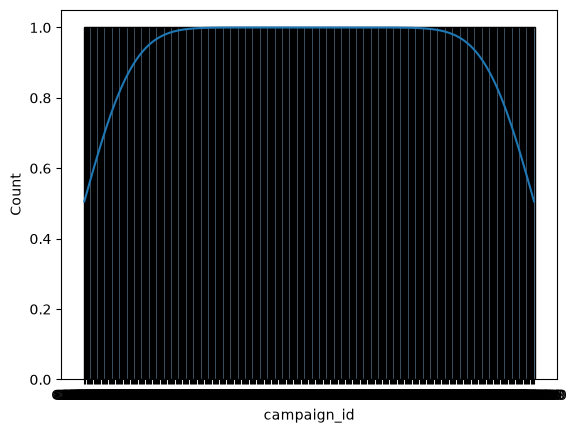

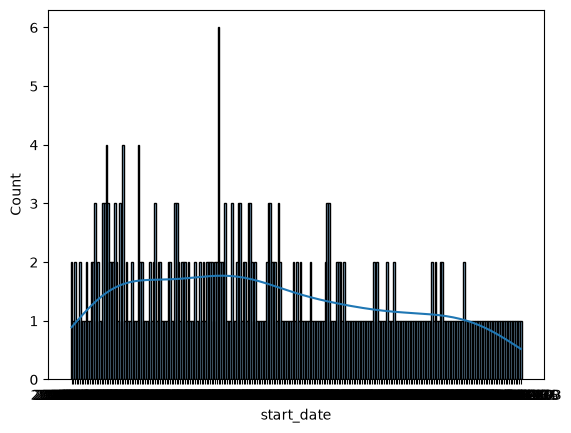

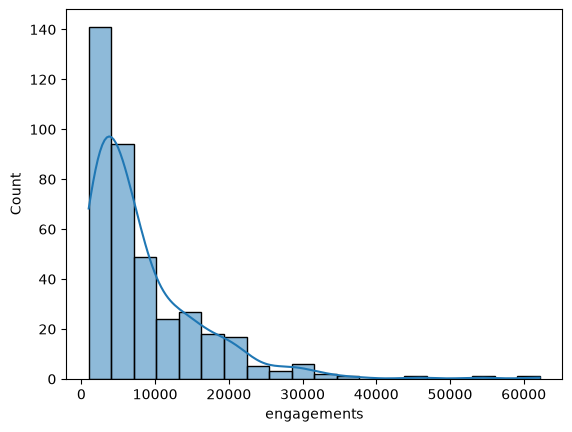

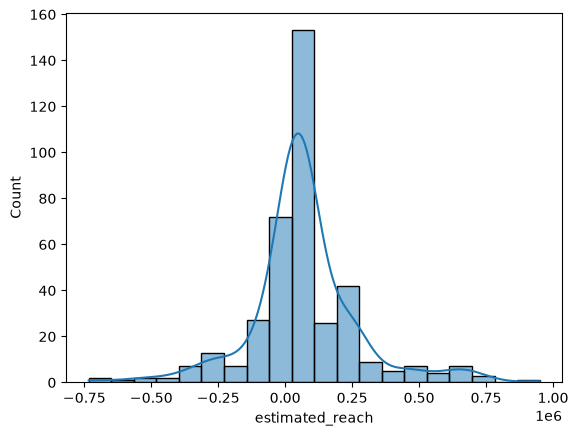

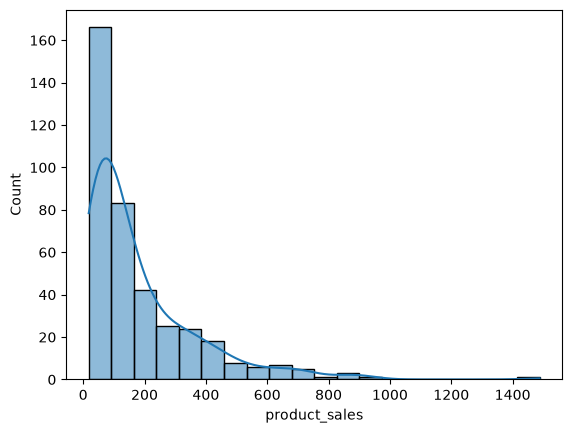

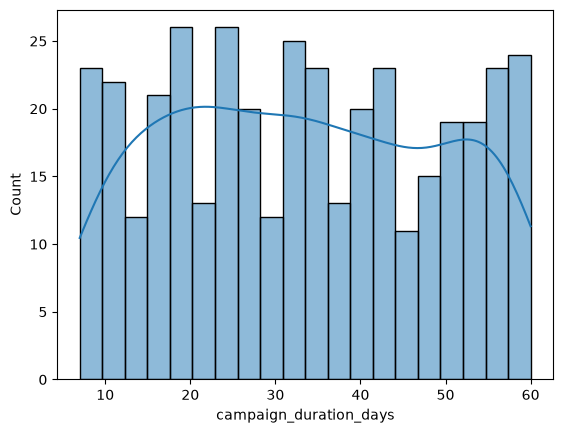

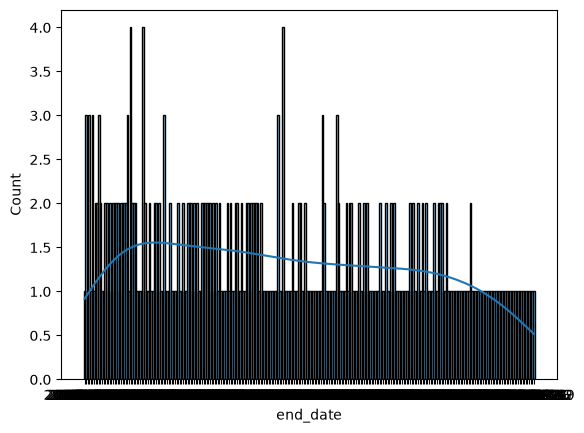

In [31]:

# uni_variate_ analysis /numeric
for i in numeric_var:
    sns.histplot(df[i],bins=20,kde=True,linewidth=1
           ,kde_kws=dict(bw_adjust=1))
    plt.show()

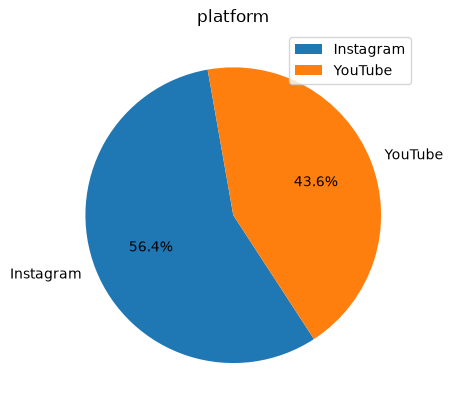

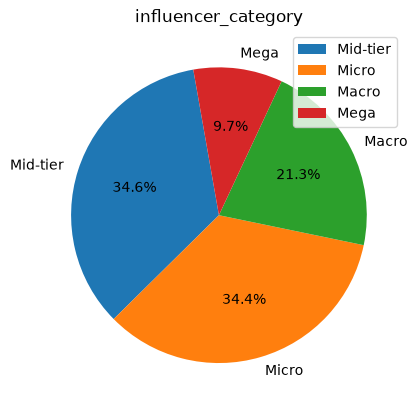

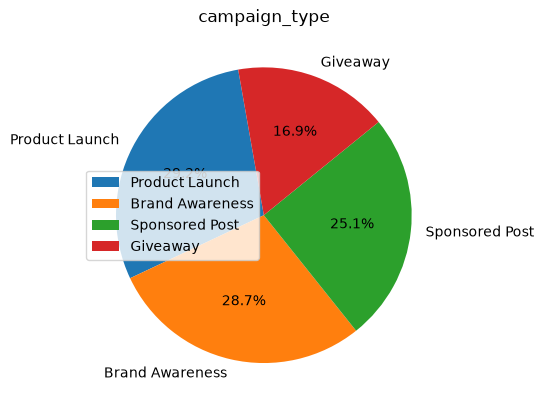

In [32]:

for i in categoric_var:
    observation_values=list(df[i].value_counts().index)
    total_observation_values=list(df[i].value_counts())
    plt.pie(total_observation_values,
            labels=observation_values,
            autopct='%1.1f%%',
            startangle=100,
            labeldistance=1.1
            )
    plt.title(i)
    plt.legend()
    plt.show()

In [33]:
df[['engagements', 'estimated_reach', 'product_sales', 'campaign_duration_days']].skew()

engagements               2.383640
estimated_reach           0.422384
product_sales             2.285991
campaign_duration_days    0.057979
dtype: float64

In [34]:
# in estimated_reach  -0.026145 we noticed  that we have negative values so we wont to remove it 
df['estimated_reach'] = df['estimated_reach'].abs()

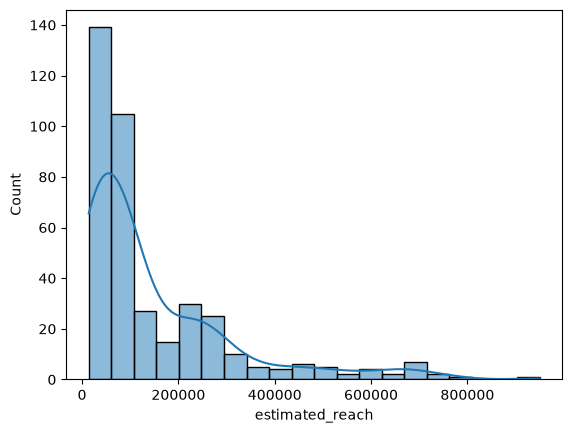

In [35]:
sns.histplot(df["estimated_reach"],bins=20,kde=True,linewidth=1
             ,edgecolor='k',kde_kws=dict(bw_adjust=1))
plt.show()

In [36]:
numeric_var.append('platform')

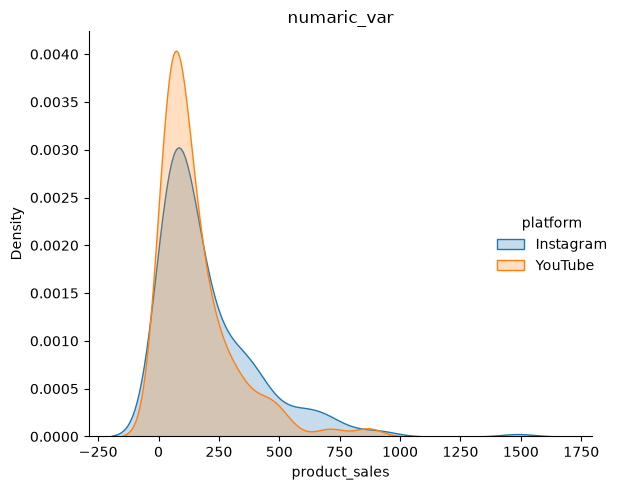

In [37]:

graphs=sns.FacetGrid(df[numeric_var], #facegrid : برسم شغلتين مع بعض ع نفس المنحنى 
                         hue="platform",  
                         height=5,
                    )
graphs.map(sns.kdeplot,"product_sales",fill=True) # تلزيق الرسمتين مع بعض 
graphs.add_legend()
plt.title("numaric_var")
plt.tight_layout()
plt.show()

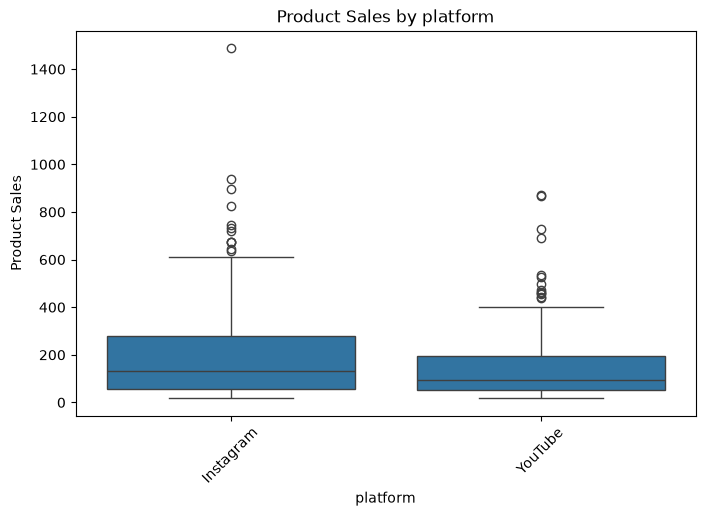

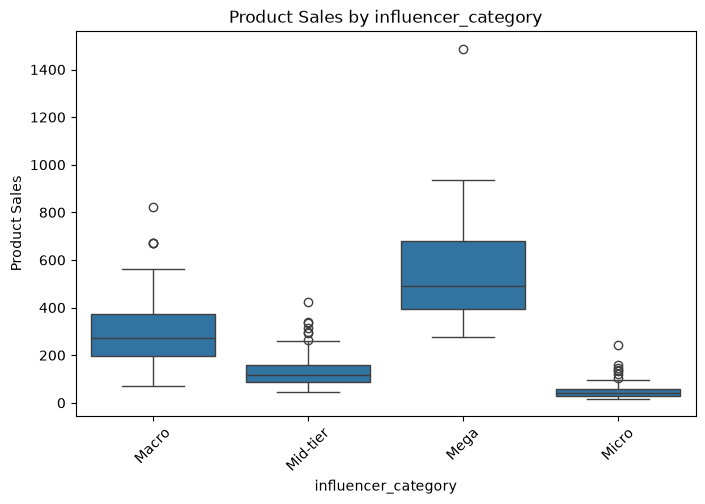

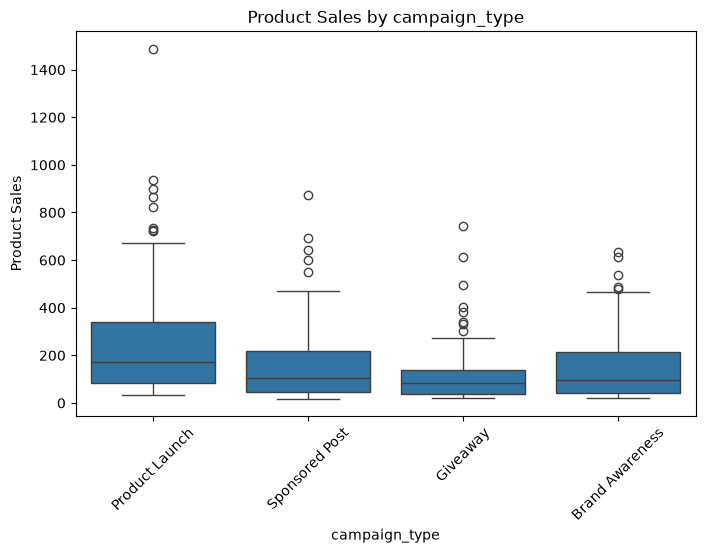

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_vars = [
    'platform',
    'influencer_category',
    'campaign_type'
]

for col in categorical_vars:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        x=df[col],
        y=df['product_sales']
    )
    
    plt.title(f'Product Sales by {col}')
    plt.xlabel(col)
    plt.ylabel('Product Sales')
    plt.xticks(rotation=45)
    plt.show()

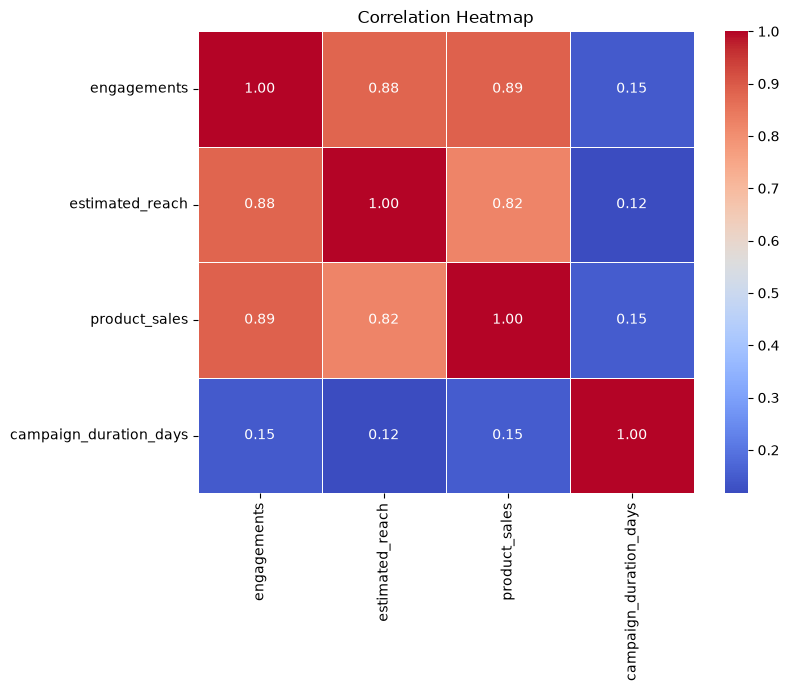

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = [
    'engagements',
    'estimated_reach',
    'product_sales',
    'campaign_duration_days'
]

# Calculate correlation 
corr = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

# 4.bulid a module

In [40]:

print("Dataset shape:", df.shape)




train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)


# Training target -> Log transformation
y_train = np.log1p(
    train_df["product_sales"]
)

# Test target stays on original scale
y_test = test_df["product_sales"]



X_train = train_df.drop(
    columns=[
        "product_sales",
        "campaign_id"
    ]
).copy()

X_test = test_df.drop(
    columns=[
        "product_sales",
        "campaign_id"
    ]
).copy()



for data in [X_train, X_test]:

    data["start_date"] = pd.to_datetime(
        data["start_date"]
    )

    data["end_date"] = pd.to_datetime(
        data["end_date"]
    )

    data["start_year"] = (
        data["start_date"].dt.year
    )

    data["start_month"] = (
        data["start_date"].dt.month
    )

    data["start_dayofweek"] = (
        data["start_date"].dt.dayofweek
    )

    data.drop(
        columns=[
            "start_date",
            "end_date"
        ],
        inplace=True
    )



for data in [X_train, X_test]:

    # Engagement Rate
    data["engagement_rate"] = (
        data["engagements"] /
        (data["estimated_reach"] + 1)
    )

    # Reach per Day
    data["reach_per_day"] = (
        data["estimated_reach"] /
        (data["campaign_duration_days"] + 1)
    )

    # Engagements per Day
    data["engagements_per_day"] = (
        data["engagements"] /
        (data["campaign_duration_days"] + 1)
    )

    # Reach × Duration
    data["reach_duration_interaction"] = (
        data["estimated_reach"] *
        data["campaign_duration_days"]
    )

    # Reach × Engagement
    data["reach_engagement_interaction"] = (
        data["estimated_reach"] *
        data["engagements"]
    )



# أنت معرف categoric_var عندك مسبقًا

for col in categoric_var:

    X_train[col] = X_train[col].astype(str)

    X_test[col] = X_test[col].astype(str)



bins = pd.qcut(
    train_df["product_sales"],
    q=10,
    labels=False,
    duplicates="drop"
)

kf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)



cat_params = {

    "iterations": 1800,

    "learning_rate": 0.02,

    "depth": 4,

    "l2_leaf_reg": 8,

    "loss_function": "RMSE",

    "bootstrap_type": "Bernoulli",

    "subsample": 0.85,

    "random_strength": 1.0,

    "min_data_in_leaf": 5,

    "border_count": 128,

    "thread_count": -1,

    "random_seed": 42,

    "verbose": False
}



cat_oof = np.zeros(
    len(train_df)
)

cat_scores = []


for fold, (train_idx, valid_idx) in enumerate(
    kf.split(X_train, bins), 1
):

    print("=" * 50)
    print("CatBoost Fold", fold)

    # Training data
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    # Validation data
    X_val = X_train.iloc[valid_idx]
    y_val = y_train.iloc[valid_idx]

    # Create CatBoost model
    model_cat = CatBoostRegressor(
        **cat_params
    )

    # Train
    model_cat.fit(
        X_tr,
        y_tr,

        cat_features=categoric_var,

        eval_set=(
            X_val,
            y_val
        ),

        early_stopping_rounds=200
    )

    # Predict validation
    pred_log = model_cat.predict(
        X_val
    )

    # Save OOF predictions
    cat_oof[valid_idx] = pred_log

    # Return from log scale
    pred = np.expm1(
        pred_log
    )

    # Prevent negative predictions
    pred = np.clip(
        pred,
        0,
        None
    )

    # Calculate RMSLE
    score = root_mean_squared_log_error(
        np.expm1(y_val),
        pred
    )

    cat_scores.append(
        score
    )

    print(
        f"RMSLE = {score:.5f}"
    )




cat_oof_pred = np.clip(
    np.expm1(cat_oof),
    0,
    None
)

cat_cv_score = root_mean_squared_log_error(
    train_df["product_sales"],
    cat_oof_pred
)

print()
print("==========================================")
print("CATBOOST CV RESULT")
print("==========================================")

print(
    f"CatBoost CV RMSLE : "
    f"{cat_cv_score:.5f}"
)




final_cat = CatBoostRegressor(
    **cat_params
)

final_cat.fit(
    X_train,
    y_train,

    cat_features=categoric_var,

    verbose=False
)



# Prediction is initially on log scale
cat_test_log = final_cat.predict(
    X_test
)


# Return to original sales scale
cat_test_pred = np.expm1(
    cat_test_log
)


# Prevent negative sales
cat_test_pred = np.clip(
    cat_test_pred,
    0,
    None
)


cat_test_score = root_mean_squared_log_error(
    y_test,
    cat_test_pred
)





print()
print("==========================================")
print("FINAL CATBOOST TEST RESULT")
print("==========================================")

print(
    f"CatBoost Test RMSLE : "
    f"{cat_test_score:.5f}"
)

print("==========================================")

Dataset shape: (390, 10)
Training data: (312, 10)
Testing data : (78, 10)
CatBoost Fold 1
RMSLE = 0.15832
CatBoost Fold 2
RMSLE = 0.22944
CatBoost Fold 3
RMSLE = 0.21794
CatBoost Fold 4
RMSLE = 0.22893
CatBoost Fold 5
RMSLE = 0.18379
CatBoost Fold 6
RMSLE = 0.18644
CatBoost Fold 7
RMSLE = 0.14141
CatBoost Fold 8
RMSLE = 0.23947
CatBoost Fold 9
RMSLE = 0.25821
CatBoost Fold 10
RMSLE = 0.16723

CATBOOST CV RESULT
CatBoost CV RMSLE : 0.20444

FINAL CATBOOST TEST RESULT
CatBoost Test RMSLE : 0.20351
